# 6-A2 作業：交易所出入金策略研發

[![在 Colab 開啟](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/finlab-python/hahow-crypto-course/blob/main/6-A2_exchange_flows.ipynb)

**對應影片**：第 6 章 作業 6-A2【籌碼面】交易所出入金策略研發

**和影片的差異**

- 影片使用 Glassnode API，但 Glassnode 已經不提供免費 API（舊金鑰會回覆「需要 API addon」）。本單元改用免金鑰的公開資料：交易所流入 / 流出量改用 Coin Metrics 社群版的 `FlowInExNtv`、`FlowOutExNtv`（每日 BTC 數量）。
- 影片中免費版 Glassnode 只到 2019 年底；新資料到最近一天，所以回測不再限定 2019 年以前。
- 進出場條件先放一個能執行的範例，請改成你自己的版本。

Exchange Transfer Volume 是使用者每天把比特幣轉進交易所、或從交易所轉出來的總量：

- `tin`：流 **進** 交易所的數量（transfer in）
- `tout`：流 **出** 交易所的數量（transfer out）

想像兩個情境：

1. 什麼時候會把 BTC 轉到交易所？想賣掉換成其他幣的時候 → 供給變多，價格容易跌
2. 什麼時候會把 BTC 從交易所轉走？想長期存起來的時候 → 供給變少，價格不容易跌

所以 `tin` 越少越好、`tout` 越多越好，代表這幾天有支撐甚至上漲的力道。
下面把 `tout / tin` 做成指標，研發一個效能類似的策略吧！此作業也會用到停損（`sl_stop`），
請參考 [4-1 筆記本](https://colab.research.google.com/github/finlab-python/hahow-crypto-course/blob/main/4-1_backtest_platform.ipynb) 最後的「補充：停損、停利、移動停損」。

In [1]:
%pip install -q finlab_crypto==0.3.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
# QUICK_RUN = True 會縮小最佳化範圍，幾十秒就跑完（自動測試使用）。上課請維持 False。
QUICK_RUN = False

In [3]:
import numpy as np
import finlab_crypto
from finlab_crypto import onchain

finlab_crypto.setup()
ohlcv = finlab_crypto.crawler.get_all_binance('BTCUSDT', '1d')

BTCUSDT 1d: 3326 candles (2017-08-17 ~ 2026-09-24 00:00 UTC)


# 取得 tin 與 tout

資料來源：[Coin Metrics Community Data](https://coinmetrics.io/community-network-data/)（CC BY-NC 4.0，公開分享結果時請註明）。

In [4]:
flows = onchain.coinmetrics(['FlowInExNtv', 'FlowOutExNtv'])
tin = onchain.align(flows.FlowInExNtv, ohlcv.index)
tout = onchain.align(flows.FlowOutExNtv, ohlcv.index)

## 把 tin 與 tout 畫出來

<Axes: xlabel='timestamp'>

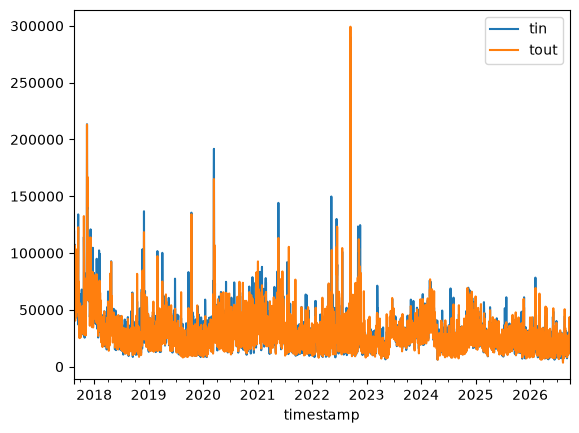

In [5]:
tin.plot(label='tin', legend=True)
tout.plot(label='tout', legend=True)

## 製作 tout / tin 的比率

<Axes: xlabel='timestamp'>

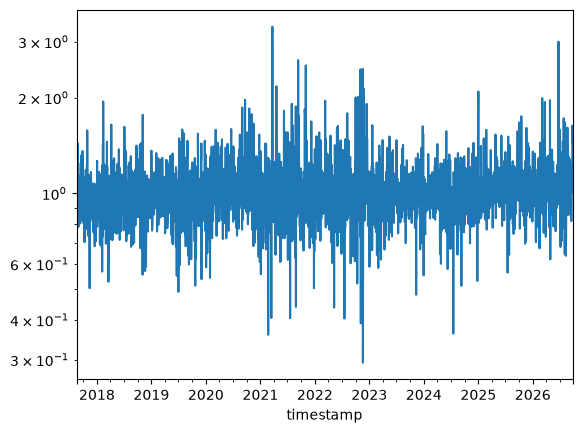

In [6]:
ratio = tout / tin
ratio.plot(logy=True)

## 研發策略

在 `tout / tin` 上升或偏高時買進 BTC，反之賣出。
範例用「快線在慢線之上」進場，請改寫 `entries`、`exits` 兩行。

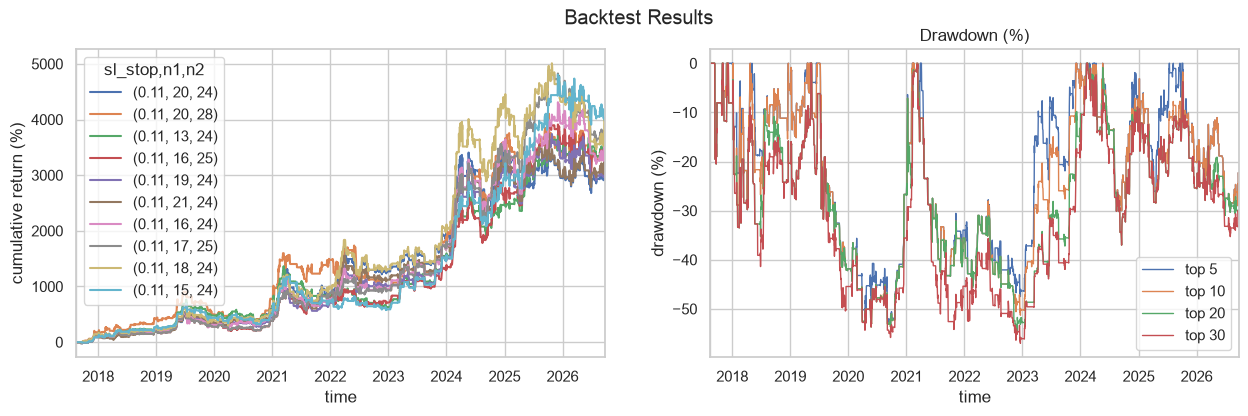

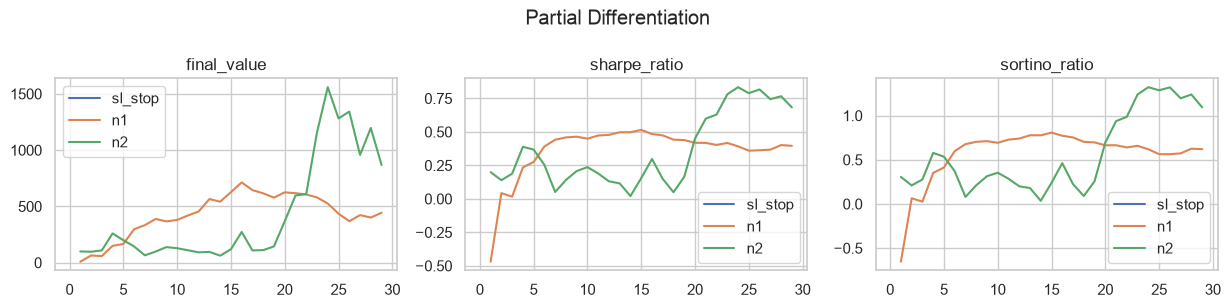

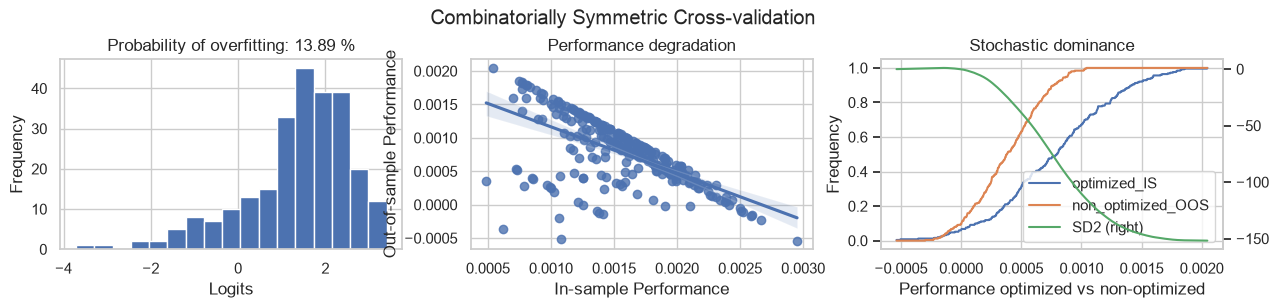

In [7]:
from finlab_crypto.indicators import trends


@finlab_crypto.Strategy(n1=10, n2=20)
def tcount_strategy(ohlcv):
    ma1 = trends['hullma'](ratio, tcount_strategy.n1)
    ma2 = trends['sma'](ratio, tcount_strategy.n2)

    ######################################
    # TODO: 請自己設計進出場條件
    entries = (ma1 > ma2) & (ma1.shift() < ma2.shift())
    exits = (ma1 < ma2) & (ma1.shift() > ma2.shift())
    ######################################

    figures = {
        'figures': {
            'flow_ratio': {
                'sma1': ma1,
                'sma2': ma2,
                'value': ratio,
            }
        }
    }
    return entries, exits, figures


step = 7 if QUICK_RUN else 1
tcount_strategy.backtest(ohlcv, variables={
    'n1': np.arange(1, 30, step),
    'n2': np.arange(1, 30, step),
    'sl_stop': 0.11,
}, freq='1d', plot=True)